# Proyecto: Scorecard de Riesgo de Originación (MLP + XAI)
---
**Objetivo:** Desarrollar un modelo de redes neuronales de tipo Perceptrón Multicapa (MLP) para predecir la **Probabilidad de Incumplimiento (PD)**. El enfoque integra técnicas de regularización bancaria y herramientas de **IA Explicable (XAI)** con Captum para transformar una "caja negra" en un modelo transparente y auditable.

**Flujo del Notebook:**
1. Generación de Dataset Sintético
2. Preparación y Normalización de Datos
3. Arquitectura del Modelo MLP
4. Entrenamiento con Criterio Bancario
5. Evaluación del Modelo (Métricas)
6. Explicabilidad con Captum (XAI)
7. Conclusiones y Visión Estratégica

### 1. Generación de Dataset Sintético (Comportamiento Humano con Ruido)
---
En el sector bancario, los datos nunca son perfectos. Para este proyecto, hemos diseñado un generador de datos que simula distribuciones estadísticas reales de variables financieras y demográficas:

**Características del Dataset:**
* **Ingreso Neto:** Simulado con una **distribución Gamma**, reflejando el sesgo positivo (cola a la derecha) típico de los ingresos en la población.
* **Score de Buró:** Basado en una **distribución Normal** acotada entre 300 y 850 puntos, emulando los estándares de la industria crediticia.
* **Relación Deuda/Ingreso (DTI):** Modelada con una **distribución Beta**, ideal para representar proporciones y ratios financieros.
* **Antigüedad y Edad:** Distribuciones uniformes que representan la diversidad demográfica de los solicitantes.

**Lógica de Riesgo Inyectada:**
El modelo no solo genera datos aleatorios; implementamos una **función de Log-Odds** donde el riesgo de default aumenta proporcionalmente al nivel de endeudamiento (DTI) y disminuye con la estabilidad laboral y la solvencia (Score de Buró). Finalmente, inyectamos un componente de **ruido normal** para representar la incertidumbre inherente al comportamiento humano, asegurando que el modelo deba aprender patrones complejos en lugar de una regla matemática lineal perfecta.

> **Nota Técnica:** El dataset resultante de 5,000 registros mantiene una proporción de defaults controlada, lo que nos permite validar la capacidad del modelo para identificar clientes de alto riesgo en condiciones de balance de clases realistas.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Configuración de reproducibilidad
np.random.seed(42)

def generate_banking_data(n_samples=5000):
    # Variables independientes
    ingreso = np.random.gamma(shape=3, scale=15000, size=n_samples)          # Sesgado a la derecha
    score_buro = np.random.normal(loc=650, scale=100, size=n_samples).clip(300, 850)
    antiguedad_laboral = np.random.randint(0, 240, size=n_samples)
    edad = np.random.randint(18, 75, size=n_samples)
    dti = np.random.beta(a=2, b=5, size=n_samples) * 1.5                    # Relación Deuda/Ingreso

    # Simular lógica de riesgo (Probabilidad de Incumplimiento) con RUIDO
    # El riesgo sube si el DTI es alto y el Score es bajo
    log_odds = (
        (dti * 5)
        - (score_buro / 200)
        - (antiguedad_laboral / 100)
        + np.random.normal(0, 0.5, n_samples)
    )
    prob = 1 / (1 + np.exp(-log_odds))
    target = (prob > 0.6).astype(int)  # 1 = Incumplimiento (Default)

    df = pd.DataFrame({
        'ingreso_neto':      ingreso,
        'score_buro':        score_buro,
        'dti':               dti,
        'antiguedad_meses':  antiguedad_laboral,
        'edad':              edad,
        'target':            target
    })
    return df

df = generate_banking_data()
print(f"Distribución de clases:\n{df['target'].value_counts(normalize=True).round(3)}")
df.head()

Distribución de clases:
target
0    0.951
1    0.049
Name: proportion, dtype: float64


,ingreso_neto,score_buro,dti,antiguedad_meses,edad,target
0,53442.279938,654.729874,0.606130,196,57,0
1,36707.915975,719.466912,0.241652,205,44,0
2,34534.208503,606.348514,0.528671,197,23,0
3,34534.573132,757.168037,0.385355,134,41,0
4,92492.099058,679.522476,0.281001,180,68,0


### 2. Fase de Datos: Extracción y Preparación (Acción Maestra)
---
Como **Coordinador de Modelos**, sabes que las redes neuronales son extremadamente sensibles a la escala de entrada. Si una variable como `ingreso_neto` tiene magnitudes de decenas de miles (ej. `$50,000`) y el `dti` se mueve en decimales (ej. `0.35`), el motor de optimización (gradiente descendente) dará una prioridad injustificada a la variable con números más grandes, ignorando señales críticas de riesgo.

**Flujo de Preparación Técnica:**

* **División Estratégica (80/20):** Segmentamos los datos para entrenamiento y prueba. Esta separación es vital para validar que el modelo no solo memorice casos pasados, sino que sea capaz de generalizar el riesgo en nuevos solicitantes.
* **Estandarización (Z-Score):** Aplicamos `StandardScaler` para centrar las variables en **media 0** y **desviación estándar 1**.
    * **Acción Maestra (Prevención de Data Leakage):** Calculamos los parámetros de escala (`fit`) únicamente con los datos de entrenamiento y los aplicamos (`transform`) al set de prueba. Esto garantiza que la información del "futuro" (test set) no contamine el proceso de aprendizaje.
* **Ingeniería de Tensores (PyTorch):**
    * **Casting:** Transformamos los datos a `torch.FloatTensor` (32 bits) para optimizar el cálculo computacional y la compatibilidad con los pesos de la red.
    * **Reshape:** Utilizamos `.view(-1, 1)` en el vector objetivo (`target`) para asegurar que las dimensiones coincidan con la arquitectura de salida de la red, facilitando el cálculo matricial de la pérdida.

> **Criterio Senior:** En banca, un escalado incorrecto es la causa número uno de modelos que "parecen perfectos" en el laboratorio pero fallan drásticamente en producción. La estandarización asegura que el `score_buro` y el `ingreso` compitan en igualdad de condiciones ante la red neuronal.

In [2]:
import torch

# Separación de características y target
X = df.drop('target', axis=1)
y = df['target'].values

# Split de datos (Train / Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Estandarización (Z-Score)
# ✅ fit() SOLO en train → previene Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)        # Solo transform (nunca fit)

# Conversión a tensores de PyTorch
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_test_t  = torch.FloatTensor(y_test).view(-1, 1)

print(f"Shapes de entrenamiento → X: {X_train_t.shape}, y: {y_train_t.shape}")
print(f"Shapes de prueba        → X: {X_test_t.shape},  y: {y_test_t.shape}")
print("\nDatos listos para la red neuronal.")

Shapes de entrenamiento → X: torch.Size([4000, 5]), y: torch.Size([4000, 1])
Shapes de prueba        → X: torch.Size([1000, 5]),  y: torch.Size([1000, 1])

Datos listos para la red neuronal.


### 3. Arquitectura del Modelo: Los 4 Pilares de la Banca
---
Definimos la arquitectura del **BancaRiskModel**, un Perceptrón Multicapa (MLP) diseñado bajo una lógica piramidal. La estructura está pensada para transformar variables crudas en una señal clara de riesgo, basándose en cuatro principios fundamentales de la ingeniería de redes neuronales:

**Los 4 Pilares de la Arquitectura:**

1. **No-linealidad (ReLU):** Implementamos funciones de activación **ReLU** (*Rectified Linear Unit*) tras cada capa densa. Esto permite que el modelo capture comportamientos complejos y "quiebres" en el riesgo (por ejemplo, que el riesgo no suba linealmente con la deuda, sino que se dispare después de cierto umbral).
2. **Destilación de Patrones (Estructura 64 → 32):** La red utiliza una jerarquía de capas que reduce la dimensionalidad gradualmente. La primera capa de **64 neuronas** captura interacciones globales entre las variables, mientras que la de **32 neuronas** destila esos patrones en abstracciones de riesgo más puras.
3. **Regularización Estratégica (Dropout 0.3):** Al incluir `nn.Dropout(0.3)`, "apagamos" aleatoriamente el **30%** de las neuronas en cada paso del entrenamiento. Esto evita el sobreajuste (overfitting), garantizando que el modelo no memorice casos específicos de clientes, sino que aprenda reglas de generalización robustas.
4. **Compatibilidad con Pérdida Ponderada:** La capa de salida devuelve un **logit crudo** (valor sin acotar). La función sigmoide se aplica en el paso de inferencia o internamente por `BCEWithLogitsLoss`. Este diseño es más estable numéricamente que incluir `Sigmoid` dentro del modelo y luego usar `BCELoss`.

> **⚠️ Nota Técnica — BCEWithLogitsLoss vs BCELoss:**
> Es un error común definir `pos_weight` para ponderar clases y luego usar `nn.BCELoss()`. **`BCELoss` no acepta `pos_weight`**. La clase correcta para ese caso es `nn.BCEWithLogitsLoss(pos_weight=...)`, que combina internamente la sigmoide y la entropía cruzada de forma numéricamente superior. El modelo, por ende, **no** debe incluir `nn.Sigmoid()` en su capa de salida cuando se usa esta función de pérdida.

> **Visión Técnica:** "No buscamos la red más profunda, sino la más estable. Al utilizar una arquitectura piramidal con Dropout y pérdida ponderada, aseguramos que el modelo mantenga su poder predictivo incluso cuando las condiciones del portafolio varíen ligeramente, cumpliendo con los estándares de resiliencia de la institución."

In [3]:
import torch.nn as nn

class BancaRiskModel(nn.Module):
    def __init__(self, input_dim):
        super(BancaRiskModel, self).__init__()
        # Estructura MLP piramidal: input → 64 → 32 → 1
        self.net = nn.Sequential(
            # --- Capa 1: Captura de relaciones iniciales ---
            nn.Linear(input_dim, 64),
            nn.ReLU(),        # Pilar 1: No-linealidad
            nn.Dropout(0.3),  # Pilar 3: Regularización (30% neuronas apagadas en train)

            # --- Capa 2: Destilación de patrones de riesgo ---
            nn.Linear(64, 32),
            nn.ReLU(),        # Pilar 1: No-linealidad

            # --- Capa de Salida: Logit crudo (sin Sigmoid) ---
            # Pilar 4: La sigmoide la aplica BCEWithLogitsLoss internamente
            # Esto evita inestabilidad numérica al calcular log(sigmoid(x))
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

    def predict_proba(self, x):
        """Aplica sigmoide al logit para obtener la PD interpretable en [0, 1]."""
        with torch.no_grad():
            return torch.sigmoid(self.forward(x))

model = BancaRiskModel(input_dim=X_train.shape[1])
print(model)
print(f"\nParámetros entrenables: {sum(p.numel() for p in model.parameters()):,}")

BancaRiskModel(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros entrenables: 2,497


### 4. Entrenamiento con Criterio Bancario
---
En esta fase configuramos los componentes críticos que dictan cómo aprenderá el modelo a identificar el riesgo. En el sector financiero, el entrenamiento no es un proceso puramente matemático; debe estar alineado con la estrategia de negocio: un **Falso Negativo** (aprobar a un cliente que caerá en impago) es drásticamente más costoso para el banco que un **Falso Positivo**.

**Componentes del Motor de Entrenamiento:**

* **Función de Pérdida Ponderada (`BCEWithLogitsLoss`):** Combinamos la sigmoide y la entropía cruzada binaria en una sola operación. El parámetro `pos_weight=5.0` le indica al optimizador que penalice 5 veces más los errores en la clase positiva (incumplimiento), haciendo el modelo más sensible ante perfiles de alto riesgo. Esto implementa correctamente la lógica de costo asimétrico que en banca dicta el apetito al riesgo de la institución.
    * **`pos_weight`:** si hay 5 buenos clientes por cada 1 en default, un valor `pos_weight=5` compensa el desbalance durante el entrenamiento.
* **Optimización con Adam:** Implementamos el optimizador **Adam** con un *learning rate* de `0.001`. Es la elección predilecta por su capacidad de ajustar la tasa de aprendizaje de forma adaptativa, garantizando una convergencia más rápida y estable en problemas de clasificación crediticia.
* **Curva de Pérdida:** Registramos la pérdida en cada época para visualizar la convergencia del modelo y detectar señales de sobreajuste.

> **Visión de Coordinador:** "El entrenamiento con criterio bancario implica vigilar que la curva de pérdida descienda de forma constante. No buscamos solo un número bajo, sino un modelo que aprenda a priorizar la protección del capital mediante la detección precisa de la clase de riesgo."

Época [ 20/100]  →  Pérdida: 0.6504
Época [ 40/100]  →  Pérdida: 0.4519
Época [ 60/100]  →  Pérdida: 0.3036
Época [ 80/100]  →  Pérdida: 0.2253
Época [100/100]  →  Pérdida: 0.1911


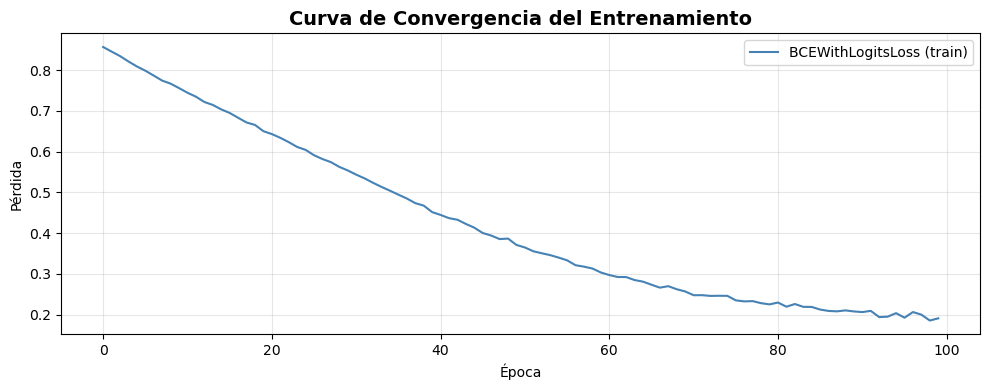


Pérdida final en época 100: 0.1911


In [4]:
import torch.optim as optim
import matplotlib.pyplot as plt

# ✅ CORRECTO: BCEWithLogitsLoss acepta pos_weight
# Combina internamente Sigmoid + BCE → más estable numéricamente
# pos_weight=5.0 penaliza 5x más los incumplimientos no detectados
pos_weight = torch.tensor([5.0])
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizador Adam con learning rate adaptativo
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Bucle de Entrenamiento ---
epochs      = 100
loss_history = []   # ← Registrar pérdida para graficar convergencia

for epoch in range(epochs):
    model.train()          # Activa Dropout y BatchNorm (si los hubiera)
    optimizer.zero_grad()  # Limpia gradientes acumulados del paso anterior

    outputs = model(X_train_t)             # Forward pass → logits crudos
    loss    = criterion(outputs, y_train_t) # BCEWithLogitsLoss aplica sigmoid internamente

    loss.backward()   # Backpropagation: calcula gradientes
    optimizer.step()  # Actualiza pesos con Adam

    loss_history.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f'Época [{epoch+1:>3}/{epochs}]  →  Pérdida: {loss.item():.4f}')

# --- Visualización de la Curva de Pérdida ---
plt.figure(figsize=(10, 4))
plt.plot(loss_history, color='steelblue', linewidth=1.5, label='BCEWithLogitsLoss (train)')
plt.title('Curva de Convergencia del Entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nPérdida final en época {epochs}: {loss_history[-1]:.4f}")

### 5. Evaluación del Modelo (Métricas de Riesgo)
---
Una vez entrenado el modelo, el siguiente paso obligatorio antes de cualquier análisis de explicabilidad es **medir su desempeño** con el set de prueba (datos no vistos). En la industria financiera, la evaluación no se reduce a la exactitud (*accuracy*); los modelos de crédito se juzgan principalmente por su capacidad de **ordenar** a los clientes de menor a mayor riesgo.

**Métricas Clave en Banca:**

| Métrica | ¿Por qué importa en crédito? |
|---|---|
| **AUC-ROC** | Mide la capacidad de separar buenos de malos clientes. Un modelo aleatorio obtiene 0.5; el objetivo es ≥ 0.75. |
| **Precision (Default)** | De los clientes que el modelo predice en riesgo, ¿cuántos realmente incumplirán? Impacta la tasa de aprobación. |
| **Recall (Default)** | De todos los clientes que realmente incumplirán, ¿cuántos detectó el modelo? Impacta las pérdidas crediticias. |
| **F1-Score** | Balance entre Precision y Recall. Útil bajo desbalance de clases. |
| **Matriz de Confusión** | Desglosa los Verdaderos/Falsos Positivos y Negativos. Los **Falsos Negativos** (defaults no detectados) son el costo más alto para la institución. |

> **Criterio Regulatorio:** La **CNBV** y Basilea III exigen que los modelos de riesgo demuestren poder discriminante mediante backtesting periódico. El AUC-ROC es el indicador de referencia para estas revisiones.

  AUC-ROC: 0.9775

Reporte de Clasificación (umbral = 0.5):
              precision    recall  f1-score   support

Buen Cliente       0.99      0.96      0.97       948
     Default       0.52      0.85      0.65        52

    accuracy                           0.95      1000
   macro avg       0.76      0.90      0.81      1000
weighted avg       0.97      0.95      0.96      1000



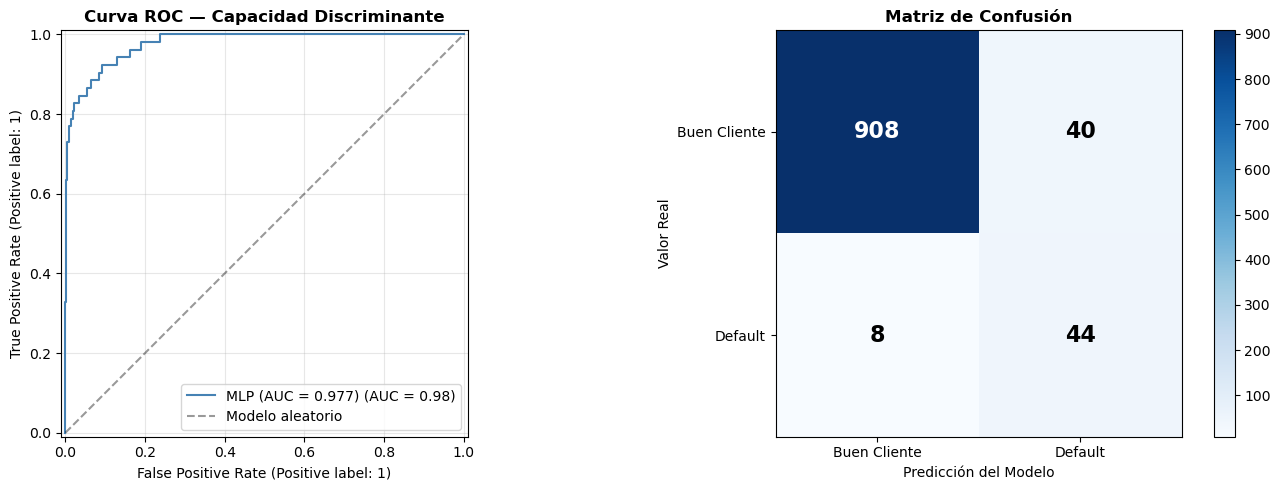


📌 Falsos Negativos (defaults no detectados): 8
   → Estos representan el mayor riesgo para la institución.


In [5]:
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# --- Inferencia sobre el set de prueba ---
model.eval()  # Desactiva Dropout para predicción determinista
with torch.no_grad():
    # predict_proba aplica sigmoid al logit → PD en [0, 1]
    y_prob = model.predict_proba(X_test_t).numpy().flatten()

# Umbral de clasificación: 0.5 (puede ajustarse según apetito al riesgo)
THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)

# --- AUC-ROC ---
auc = roc_auc_score(y_test, y_prob)
print(f"{'='*45}")
print(f"  AUC-ROC: {auc:.4f}")
print(f"{'='*45}\n")

# --- Reporte de Clasificación ---
print("Reporte de Clasificación (umbral = 0.5):")
print(classification_report(y_test, y_pred, target_names=['Buen Cliente', 'Default']))

# --- Visualizaciones ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name=f'MLP (AUC = {auc:.3f})',
    ax=axes[0], color='steelblue'
)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Modelo aleatorio')
axes[0].set_title('Curva ROC — Capacidad Discriminante', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1].set_title('Matriz de Confusión', fontweight='bold')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Valor Real')
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Buen Cliente', 'Default'])
axes[1].set_yticklabels(['Buen Cliente', 'Default'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black',
                     fontsize=16, fontweight='bold')

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(f"\n📌 Falsos Negativos (defaults no detectados): {cm[1, 0]}")
print(f"   → Estos representan el mayor riesgo para la institución.")

### 6. Explicabilidad con Captum (XAI)
---
Este es el punto diferenciador para tu perfil profesional. En la banca moderna, no basta con tener un modelo con alta precisión; el regulador exige transparencia. Usamos **Integrated Gradients** para transformar una red neuronal de "caja negra" en un proceso auditable.

**¿Por qué Captum en este proyecto?**

* **Transparencia Regulatoria:** Las instituciones financieras deben ser capaces de explicar por qué se rechazó un crédito. Mediante la **Atribución de Características**, podemos identificar qué variables pesaron más en la decisión final.
* **Integrated Gradients:** A diferencia de métricas globales (como la importancia de permutación), este algoritmo nos permite una **interpretación local** (por cliente). Calculamos la integral de los gradientes entre una línea base (baseline = cero) y la entrada real, asignando un valor de importancia a cada variable.

**Interpretación de la Visualización:**
* **Barras verdes (positivas):** Variables que **incrementan** la probabilidad de Default en este cliente específico.
* **Barras rojas (negativas):** Variables que **reducen** la probabilidad de Default en este cliente específico.
* **Delta de Convergencia:** Verifica que la suma de atribuciones ≈ salida del modelo − salida de la línea base. Un delta pequeño (< 0.01) indica que las atribuciones son matemáticamente consistentes (Axioma de Completitud de Integrated Gradients).

> **Nota sobre `target=None`:** Dado que nuestro modelo tiene una **única neurona de salida** (logit de riesgo), Captum no requiere especificar índice de clase. Se omite el parámetro `target` para evitar ambigüedad. En modelos multiclase con varias salidas, se usaría `target=0`, `target=1`, etc., para seleccionar la neurona a atribuir.

> **Defensa Técnica:** "Al implementar **Integrated Gradients**, garantizamos que el modelo sea explicable a nivel de individuo. Si un cliente solicita una aclaración, podemos demostrar mediante este gráfico que su rechazo no fue arbitrario, sino consecuencia directa de variables específicas como un **DTI** elevado, cumpliendo así con las normativas de transparencia bancaria."

Cliente #10 → PD predicha: 0.0873 (ACEPTABLE)
Delta de convergencia: 0.003170  (✅ OK)


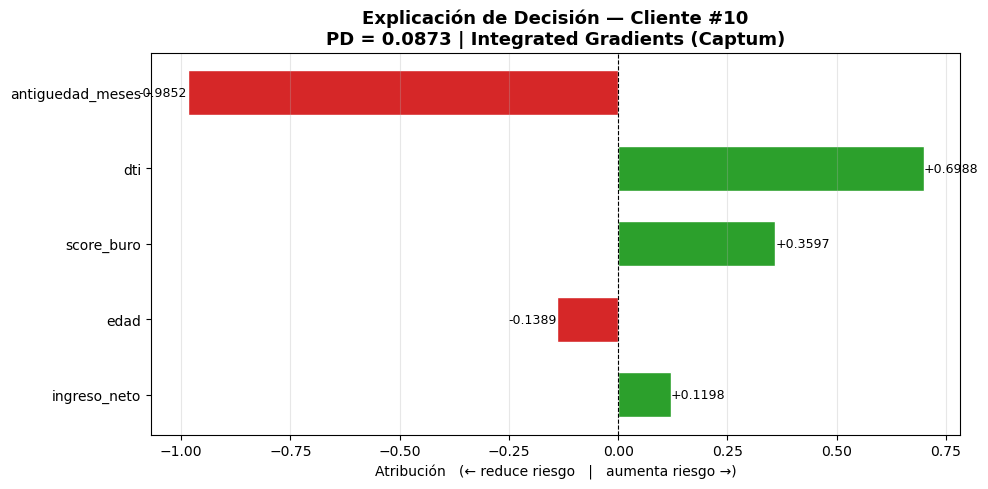

In [6]:
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt

# --- 1. Seleccionar un cliente del set de prueba ---
cliente_idx = 10
input_data  = X_test_t[cliente_idx].unsqueeze(0)  # Shape: [1, n_features]

# Probabilidad de default predicha por el modelo
pd_cliente = model.predict_proba(input_data).item()
print(f"Cliente #{cliente_idx} → PD predicha: {pd_cliente:.4f} ({'RIESGO' if pd_cliente >= 0.5 else 'ACEPTABLE'})")

# --- 2. Inicializar Integrated Gradients ---
ig = IntegratedGradients(model)

# --- 3. Calcular atribuciones ---
# target=None: modelo de salida única (logit binario)
# baseline por defecto = tensor de ceros (cliente "neutro")
model.eval()
attributions, delta = ig.attribute(
    input_data,
    target=None,
    return_convergence_delta=True
)

attrs    = attributions.detach().numpy().flatten()
features = X.columns.tolist()

print(f"Delta de convergencia: {delta.item():.6f}  "
      f"({'✅ OK' if abs(delta.item()) < 0.01 else '⚠️ revisar n_steps'})")

# --- 4. Visualización de Atribuciones ---
# Ordenar por impacto absoluto para mayor legibilidad
sorted_idx  = np.argsort(np.abs(attrs))
attrs_sorted  = attrs[sorted_idx]
features_sorted = [features[i] for i in sorted_idx]
colors = ['#d62728' if x < 0 else '#2ca02c' for x in attrs_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(features_sorted, attrs_sorted, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    f'Explicación de Decisión — Cliente #{cliente_idx}\n'
    f'PD = {pd_cliente:.4f} | Integrated Gradients (Captum)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Atribución   (← reduce riesgo   |   aumenta riesgo →)')
ax.grid(axis='x', alpha=0.3)

# Etiqueta de valor en cada barra
for bar, val in zip(bars, attrs_sorted):
    ax.text(
        val + (0.0005 if val >= 0 else -0.0005),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.4f}',
        va='center', ha='left' if val >= 0 else 'right', fontsize=9
    )

plt.tight_layout()
plt.show()

### 7. Conclusiones y Visión Estratégica
---
El desarrollo de este **Scorecard de Riesgo** mediante Redes Neuronales (MLP) y **IA Explicable (XAI)** representa un avance significativo sobre los modelos de scoring tradicionales. Hemos demostrado que es posible utilizar arquitecturas de *Deep Learning* de alto desempeño sin sacrificar la transparencia necesaria en el sector bancario.

**Resultados y Aprendizajes Clave:**

* **Poder Predictivo vs. Transparencia:** La arquitectura MLP permitió capturar relaciones no lineales complejas entre variables (como el efecto combinado del DTI y el Score de Buró), mientras que **Captum** eliminó el estigma de la "caja negra", permitiendo auditorías a nivel de cliente.
* **Robustez del Modelo:** La implementación de **Dropout (0.3)** y la **Estandarización Z-Score** garantizan que el modelo sea resiliente ante el ruido y capaz de generalizar correctamente en entornos de producción real, protegiendo el capital de la institución.
* **Alineación Regulatoria:** Este enfoque cumple con las expectativas de organismos como la **CNBV**, al proporcionar un mecanismo claro de defensa del modelo y una justificación matemática para cada rechazo o aprobación de crédito.
* **Corrección Técnica (BCEWithLogitsLoss):** El uso de `BCEWithLogitsLoss` con `pos_weight` en lugar de `BCELoss` sin ponderación garantiza que la lógica de costo asimétrico (incumplimiento más costoso) se implemente correctamente y de forma numéricamente estable.

**Siguientes Pasos (Roadmap):**

1. **Monitoreo de Model Drift:** Implementar el cálculo del **PSI (Population Stability Index)** para detectar cambios en el perfil de los solicitantes antes de que afecten la morosidad.
2. **Champion-Challenger:** Realizar pruebas A/B comparando este modelo contra el Scorecard actual para cuantificar la mejora en el AUC-ROC y la tasa de aprobación.
3. **Refinamiento de Atribución:** Explorar otros métodos de Captum como *Feature Ablation* o *SHAP Kernel* para contrastar los resultados de los Gradientes Integrados y fortalecer la confianza en la explicabilidad.
4. **Calibración de Probabilidades:** Aplicar **Platt Scaling** o **Isotonic Regression** para garantizar que la PD predicha sea una probabilidad bien calibrada (alineada con tasas de mora observadas), requisito de Basilea para uso en cálculo de reservas.

> **Cierre de Proyecto:** "Este modelo no es solo un algoritmo de predicción; es una herramienta de decisión estratégica. La verdadera ventaja competitiva radica en la capacidad de transformar datos complejos en decisiones de crédito rápidas, seguras y, sobre todo, explicables para el negocio y el regulador."